In [74]:
## Installing Packages 

import numpy as np 
import pandas as pd 
import sklearn as sk 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.datasets import make_classification 
from sklearn.model_selection import (
    train_test_split 
) 

from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import (
    BaggingClassifier, RandomForestClassifier, AdaBoostClassifier 
)

In [75]:
np.random.seed(1) 
X_toy, y_toy = make_classification(
    n_samples = 1000, n_features = 20, 
    n_informative=10, n_redundant = 5, random_state=1 
) 

X_tr, X_te, y_tr, y_te = train_test_split(X_toy, y_toy, test_size=.3) 

single_tree = DecisionTreeClassifier(random_state=21).fit(X_tr, y_tr)  
forest_100 = RandomForestClassifier(n_estimators=100, random_state=1).fit(X_tr, y_tr) 

In [76]:
single_tree_score = single_tree.score(X_te, y_te) 
random_forest_score = forest_100.score(X_te, y_te) 

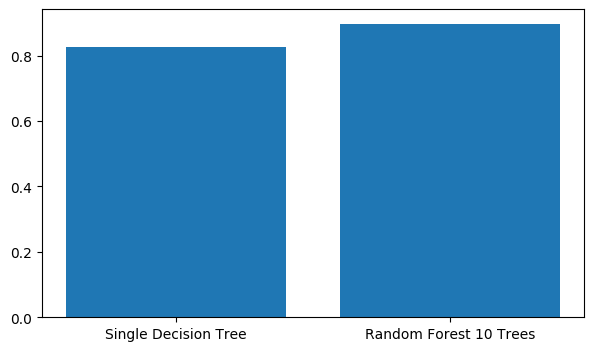

In [77]:
fig, ax = plt.subplots(figsize=(7,4)) 
bars = ax.bar(['Single Decision Tree', 'Random Forest 10 Trees'], [single_tree_score, random_forest_score]) 

In [116]:
files = ['QCM3.csv', 'QCM6.csv', 'QCM7.csv', 'QCM10.csv', 'QCM12.csv'] 


dfs = [] 
for file in files:  
    df = pd.read_csv("QCM Sensor Alcohol Dataset 2/" + file, delimiter=";") 
    dfs.append(df) 

df = pd.concat(dfs, ignore_index = False) 


In [117]:
df.tail() 

,0.799_0.201,0.799_0.201.1,0.700_0.300,0.700_0.300.1,0.600_0.400,0.600_0.400.1,0.501_0.499,0.501_0.499.1,0.400_0.600,0.400_0.600.1,1-Octanol,1-Propanol,2-Butanol,2-propanol,1-isobutanol
20,-54.35,-56.09,-88.23,-90.54,-128.65,-132.19,-173.71,-179.36,-231.30,-239.19,0,0,0,0,1
21,-56.14,-57.35,-90.74,-92.60,-132.16,-135.36,-178.79,-183.93,-239.06,-246.53,0,0,0,0,1
22,-57.71,-58.37,-92.83,-93.91,-134.83,-137.56,-182.33,-187.16,-243.12,-250.30,0,0,0,0,1
23,-58.36,-58.92,-94.31,-95.13,-136.44,-138.96,-184.70,-189.32,-246.15,-252.80,0,0,0,0,1
24,-59.00,-59.26,-94.97,-95.51,-137.28,-139.36,-186.98,-191.19,-248.98,-255.23,0,0,0,0,1


In [119]:
# target labels
targets = {
    '1-Octanol': [1, 0, 0, 0, 0],
    '1-Propanol': [0, 1, 0, 0, 0],
    '2-Butanol': [0, 0, 1, 0, 0],
    '2-propanol': [0, 0, 0, 1, 0],
    '1-isobutanol': [0, 0, 0, 0, 1] # Ejemplo con puros ceros
}
 
columns_target = ['1-Octanol', '1-Propanol', '2-Butanol', '2-propanol', '1-isobutanol']
df["target"] = df[columns_target].idxmax(axis=1)

In [120]:
df.head() 

X = df.drop(labels = ['1-Octanol', '1-Propanol', '2-Butanol', '2-propanol', '1-isobutanol', 'target'], axis =1 )
y = df['target'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3) 

0.8421052631578947
0.9210526315789473


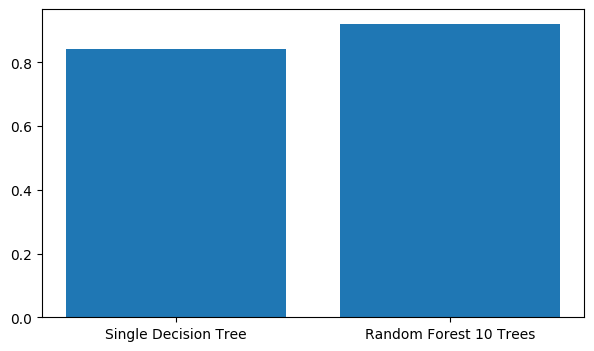

In [122]:
single_tree = DecisionTreeClassifier().fit(X_train, y_train)  
forest_100 = RandomForestClassifier(n_estimators=10, random_state=1).fit(X_train, y_train) 

single_tree_score = single_tree.score(X_test, y_test) 
random_forest_score = forest_100.score(X_test, y_test) 

print(single_tree_score) 
print(random_forest_score)

fig, ax = plt.subplots(figsize=(7,4)) 
bars = ax.bar(['Single Decision Tree', 'Random Forest 10 Trees'], [single_tree_score, random_forest_score]) 